import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries loaded!")
print(f"Pandas: {pd.__version__}")

In [1]:
import pandas as pd

# Your exact file path
news_df = pd.read_csv(r'C:\Users\HP\OneDrive\Desktop\news-sentiment-analysis\data\raw\newsData\raw_analyst_ratings.csv')

print("=" * 50)
print("✅ DATA LOADED SUCCESSFULLY!")
print("=" * 50)
print(f"Total articles: {len(news_df):,}")
print(f"Columns: {news_df.columns.tolist()}")
print("\nFirst 5 rows:")
news_df.head()

✅ DATA LOADED SUCCESSFULLY!
Total articles: 1,407,328
Columns: ['Unnamed: 0', 'headline', 'url', 'publisher', 'date', 'stock']

First 5 rows:


,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [2]:
# Add headline length
news_df['headline_length'] = news_df['headline'].str.len()
news_df['word_count'] = news_df['headline'].str.split().str.len()

# Convert dates - ALTERNATIVE METHOD
news_df['date'] = pd.to_datetime(news_df['date'], errors='coerce')
news_df['date_only'] = news_df['date'].dt.date
news_df['hour'] = news_df['date'].dt.hour
news_df['month'] = news_df['date'].dt.month
news_df['day_of_week'] = news_df['date'].dt.dayofweek
news_df['year'] = news_df['date'].dt.year

# Remove rows with invalid dates
news_df = news_df.dropna(subset=['date'])

print("✅ Data prepared!")
print(f"Date range: {news_df['date_only'].min()} to {news_df['date_only'].max()}")
print(f"Total articles after cleaning: {len(news_df):,}")

✅ Data prepared!
Date range: 2011-04-27 to 2020-06-11
Total articles after cleaning: 55,987


DESCRIPTIVE STATISTICS
Total articles: 55,987
Unique stocks: 6,204
Unique publishers: 225

--- Headline Length Statistics ---
Mean length: 80.0 characters
Median length: 63.0
Min length: 12
Max length: 512
Mean words: 12.4


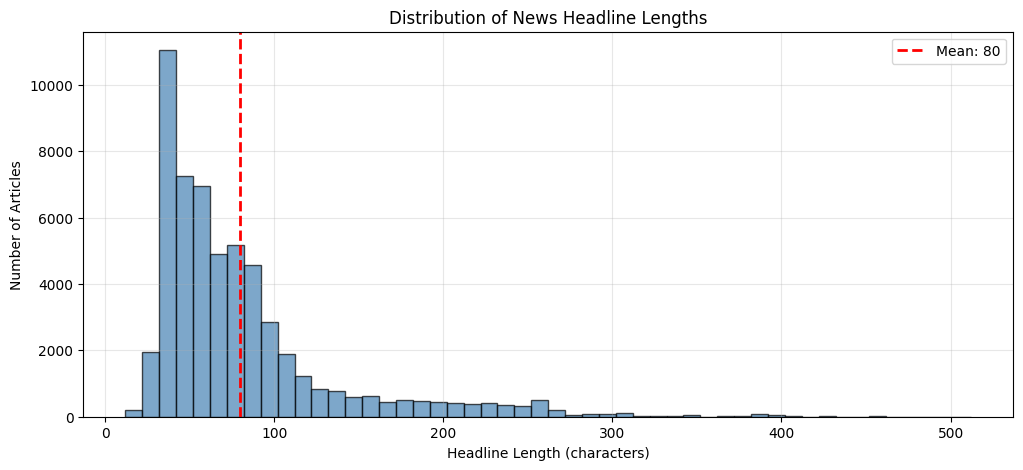

In [9]:
import matplotlib.pyplot as plt

print("=" * 60)
print("DESCRIPTIVE STATISTICS")
print("=" * 60)

print(f"Total articles: {len(news_df):,}")
print(f"Unique stocks: {news_df['stock'].nunique():,}")
print(f"Unique publishers: {news_df['publisher'].nunique():,}")

print("\n--- Headline Length Statistics ---")
print(f"Mean length: {news_df['headline_length'].mean():.1f} characters")
print(f"Median length: {news_df['headline_length'].median():.1f}")
print(f"Min length: {news_df['headline_length'].min()}")
print(f"Max length: {news_df['headline_length'].max()}")
print(f"Mean words: {news_df['word_count'].mean():.1f}")

# Histogram - Visualization 1
plt.figure(figsize=(12, 5))
plt.hist(news_df['headline_length'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
plt.axvline(news_df['headline_length'].mean(), color='red', linestyle='--', linewidth=2,
            label=f'Mean: {news_df["headline_length"].mean():.0f}')
plt.xlabel('Headline Length (characters)')
plt.ylabel('Number of Articles')
plt.title('Distribution of News Headline Lengths')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

PUBLISHER ANALYSIS
Top 10 Most Active Publishers:
publisher
Benzinga Newsdesk    14750
Lisa Levin           12408
ETF Professor         4362
Paul Quintaro         4212
Benzinga Newsdesk     3177
Benzinga Insights     2332
Vick Meyer            2128
Charles Gross         1790
Hal Lindon            1470
Benzinga_Newsdesk     1239
Name: count, dtype: int64


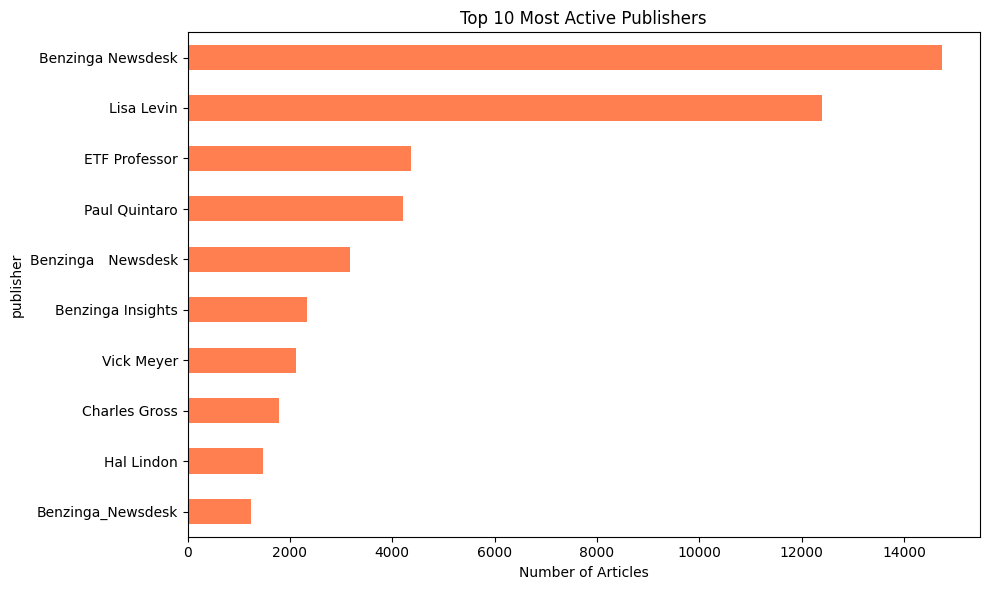

In [10]:
import matplotlib.pyplot as plt

print("=" * 60)
print("PUBLISHER ANALYSIS")
print("=" * 60)

publisher_counts = news_df['publisher'].value_counts()
print("Top 10 Most Active Publishers:")
print(publisher_counts.head(10))

# Bar chart
plt.figure(figsize=(10, 6))
publisher_counts.head(10).plot(kind='barh', color='coral')
plt.xlabel('Number of Articles')
plt.title('Top 10 Most Active Publishers')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

TIME SERIES ANALYSIS
Total trading days: 2,528
Average daily articles: 22.1
Peak day: 973 articles on 2020-03-12
Lowest day: 1 articles on 2011-04-27

📈 Top 3 News Volume Spikes:
  1. 2020-03-12: 973 articles
  2. 2020-06-05: 932 articles
  3. 2020-06-10: 806 articles


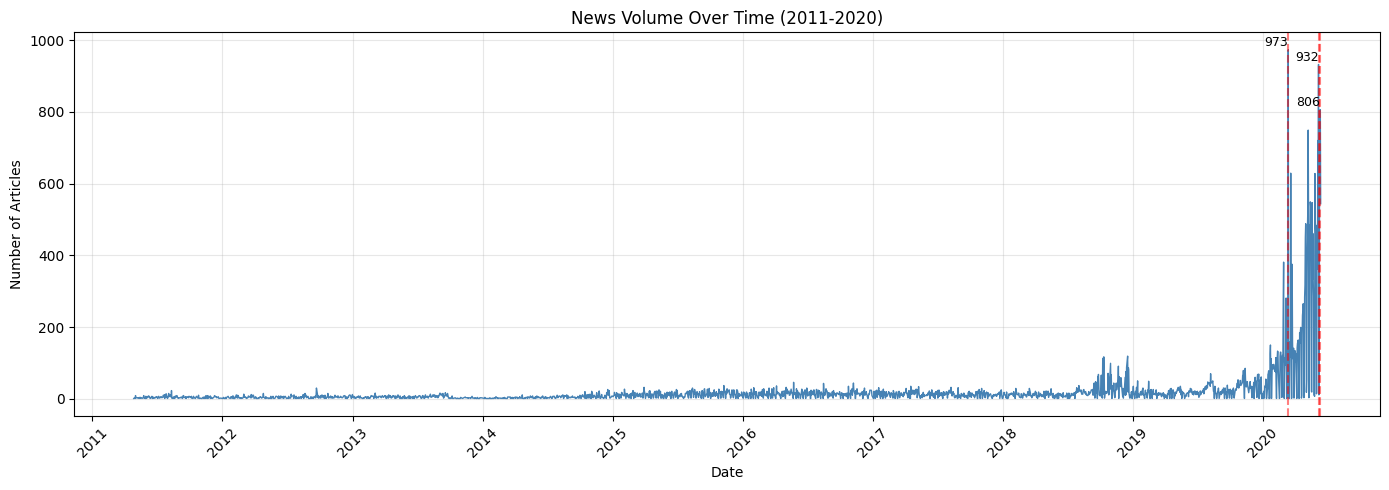

In [12]:
import matplotlib.pyplot as plt
import pandas as pd

print("=" * 60)
print("TIME SERIES ANALYSIS")
print("=" * 60)

# Daily volume
daily_volume = news_df.groupby('date_only').size()

print(f"Total trading days: {len(daily_volume):,}")
print(f"Average daily articles: {daily_volume.mean():.1f}")
print(f"Peak day: {daily_volume.max():,} articles on {daily_volume.idxmax()}")
print(f"Lowest day: {daily_volume.min():,} articles on {daily_volume.idxmin()}")

# Find top 3 spikes
top_spikes = daily_volume.nlargest(3)
print(f"\n📈 Top 3 News Volume Spikes:")
for i, (date, volume) in enumerate(top_spikes.items(), 1):
    print(f"  {i}. {date}: {volume:,} articles")

# Line chart
plt.figure(figsize=(14, 5))
plt.plot(daily_volume.index, daily_volume.values, linewidth=1, color='steelblue')
plt.xlabel('Date')
plt.ylabel('Number of Articles')
plt.title('News Volume Over Time (2011-2020)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# Highlight spikes
for date, volume in top_spikes.items():
    plt.axvline(x=pd.Timestamp(date), color='red', linestyle='--', alpha=0.5)
    plt.text(pd.Timestamp(date), volume + 10, f'{volume}', fontsize=9, ha='right')

plt.tight_layout()
plt.show()

KEYWORD ANALYSIS
Top 15 Most Common Words in Headlines:
  stocks: 12,794
  week: 9,029
  shares: 8,393
  trading: 6,575
  hit: 5,902
  eps: 5,531
  market: 5,482
  price: 5,046
  companies: 4,778
  target: 4,676
  several: 4,650
  sales: 4,429
  higher: 4,271
  estimate: 3,818
  lows: 3,741


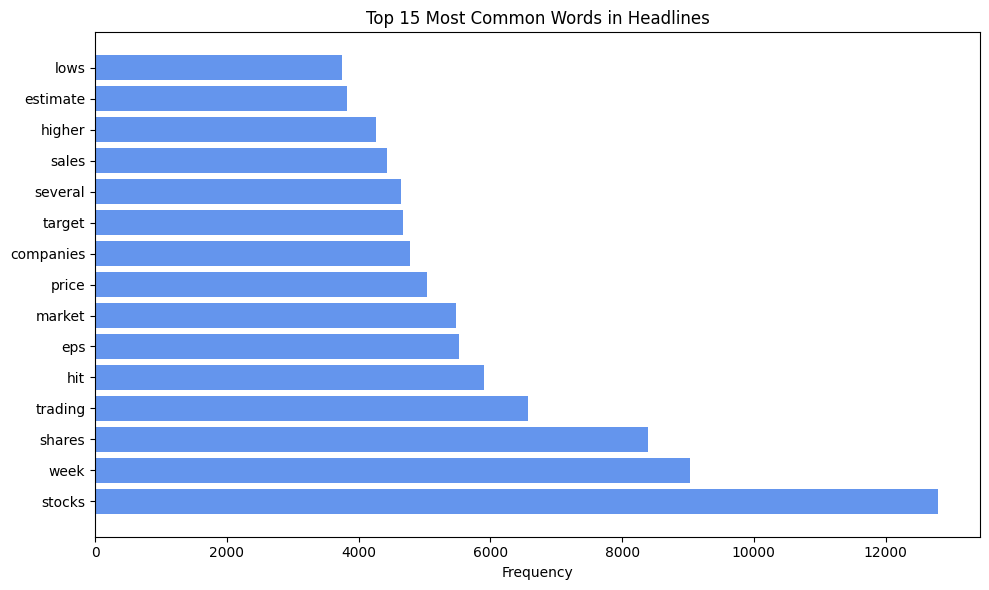

In [13]:
import matplotlib.pyplot as plt
from collections import Counter
import re

print("=" * 60)
print("KEYWORD ANALYSIS")
print("=" * 60)

# Combine all headlines
all_text = ' '.join(news_df['headline'].fillna('').astype(str))
all_text = all_text.lower()

# Find all words (3+ letters)
words = re.findall(r'\b[a-z]{3,}\b', all_text)

# Stop words to remove
stop_words = {'the', 'and', 'for', 'are', 'that', 'have', 'not', 'with', 'its', 'will',
              'from', 'this', 'they', 'was', 'but', 'has', 'were', 'their', 'been', 'can',
              'said', 'says', 'after', 'before', 'would', 'could', 'should', 'being',
              'what', 'when', 'where', 'there', 'their', 'which', 'all', 'been', 'had',
              'were', 'does', 'into', 'through', 'during', 'before', 'after'}

filtered_words = [w for w in words if w not in stop_words]
word_freq = Counter(filtered_words).most_common(15)

print("Top 15 Most Common Words in Headlines:")
for word, count in word_freq:
    print(f"  {word}: {count:,}")

# Bar chart
words_list = [w for w, c in word_freq]
counts_list = [c for w, c in word_freq]

plt.figure(figsize=(10, 6))
plt.barh(words_list, counts_list, color='cornflowerblue')
plt.xlabel('Frequency')
plt.title('Top 15 Most Common Words in Headlines')
plt.tight_layout()
plt.show()

STOCK COVERAGE ANALYSIS
Top 10 Most Covered Stocks:
stock
A       10
AA      10
AAC     10
AAL     10
AAMC    10
AAME    10
AAN     10
AAOI    10
AAON    10
AAP     10
Name: count, dtype: int64


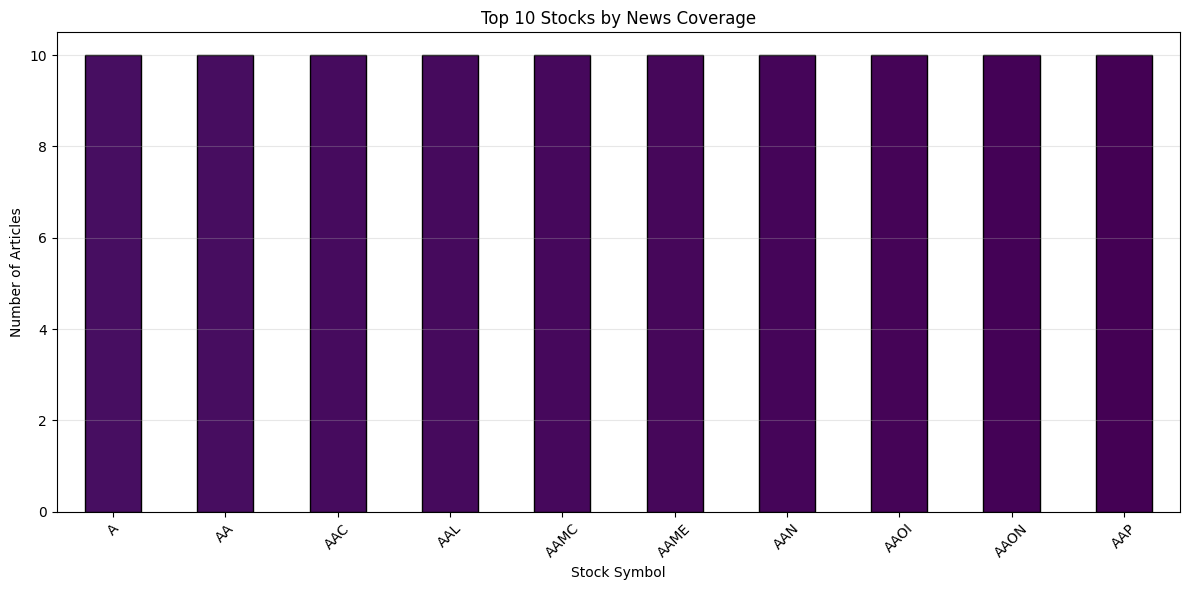


📊 The top stock has 10 articles
📊 The top 5 stocks account for 50 articles


In [14]:
import matplotlib.pyplot as plt

print("=" * 60)
print("STOCK COVERAGE ANALYSIS")
print("=" * 60)

stock_counts = news_df['stock'].value_counts().head(10)
print("Top 10 Most Covered Stocks:")
print(stock_counts)

plt.figure(figsize=(12, 6))
colors = plt.cm.viridis(range(len(stock_counts)))[::-1]
stock_counts.plot(kind='bar', color=colors, edgecolor='black')
plt.xlabel('Stock Symbol')
plt.ylabel('Number of Articles')
plt.title('Top 10 Stocks by News Coverage')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Additional insight
print(f"\n📊 The top stock has {stock_counts.iloc[0]:,} articles")
print(f"📊 The top 5 stocks account for {stock_counts.head(5).sum():,} articles")